In [21]:
# Librairies de base
import pandas as pd
import numpy as np
import pickle
from collections import Counter

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, f1_score,
    precision_recall_curve, auc
)

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Gestion du déséquilibre
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuration
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

In [23]:
# Charger le dataset
df = pd.read_csv('/content/drive/MyDrive/ML/financial_fraud_detection_dataset.csv')

print("=" * 60)
print("APERÇU DU DATASET")
print("=" * 60)
print(f"\nDimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes\n")
print(df.head())

APERÇU DU DATASET

Dimensions : 5000000 lignes × 18 colonnes

  transaction_id                   timestamp sender_account receiver_account  \
0        T100000  2023-08-22T09:22:43.516168      ACC877572        ACC388389   
1        T100001  2023-08-04T01:58:02.606711      ACC895667        ACC944962   
2        T100002  2023-05-12T11:39:33.742963      ACC733052        ACC377370   
3        T100003  2023-10-10T06:04:43.195112      ACC996865        ACC344098   
4        T100004  2023-09-24T08:09:02.700162      ACC584714        ACC497887   

    amount transaction_type merchant_category location device_used  is_fraud  \
0   343.78       withdrawal         utilities    Tokyo      mobile     False   
1   419.65       withdrawal            online  Toronto         atm     False   
2  2773.86          deposit             other   London         pos     False   
3  1666.22          deposit            online   Sydney         pos     False   
4    24.43         transfer         utilities  Toronto   


INFORMATIONS SUR LES DONNÉES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), 

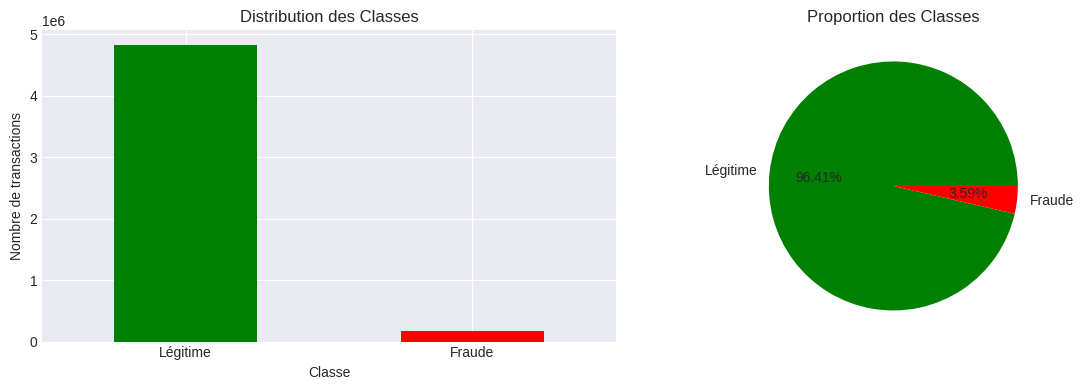

In [25]:
# EDA
print("\n" + "=" * 60)
print("INFORMATIONS SUR LES DONNÉES")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 60)
print(df.describe())

print("\n" + "=" * 60)
print("VALEURS MANQUANTES")
print("=" * 60)
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Aucune valeur manquante détectée ✓")

print("\n" + "=" * 60)
print("DISTRIBUTION DE LA VARIABLE CIBLE")
print("=" * 60)
target_col = [col for col in df.columns if 'fraud' in col.lower() or 'target' in col.lower() or 'label' in col.lower()]
if target_col:
    target_col = target_col[0]
else:
    target_col = df.columns[-1]  # Dernière colonne par défaut

print(f"Variable cible identifiée : '{target_col}'")
fraud_counts = df[target_col].value_counts()
fraud_pct = df[target_col].value_counts(normalize=True) * 100

print(f"\nRépartition :")
for val, count in fraud_counts.items():
    print(f"  Classe {val} : {count:,} ({fraud_pct[val]:.2f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fraud_counts.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Distribution des Classes')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre de transactions')
axes[0].set_xticklabels(['Légitime', 'Fraude'], rotation=0)

fraud_pct.plot(kind='pie', ax=axes[1], autopct='%1.2f%%', colors=['green', 'red'], labels=['Légitime', 'Fraude'])
axes[1].set_title('Proportion des Classes')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()


In [26]:
print("\n" + "=" * 60)
print("PRÉTRAITEMENT DES DONNÉES")
print("=" * 60)

# Copie de travail
df_clean = df.copy()

# Gestion des valeurs manquantes
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['int64', 'float64']:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Séparation features et target
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print(f"\nFeatures (X) : {X.shape}")
print(f"Target (y) : {y.shape}")

# Identification des colonnes numériques et catégorielles
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nColonnes numériques : {len(numeric_cols)}")
print(f"Colonnes catégorielles : {len(categorical_cols)}")

# Encodage des variables catégorielles
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"  Encodé : {col} ({len(le.classes_)} classes)")

# Vérification finale
print(f"\nDataset final : {X.shape}")
print("\nTypes de données :")
print(X.dtypes.value_counts())


PRÉTRAITEMENT DES DONNÉES

Features (X) : (5000000, 17)
Target (y) : (5000000,)

Colonnes numériques : 5
Colonnes catégorielles : 12
  Encodé : transaction_id (5000000 classes)
  Encodé : timestamp (4999998 classes)
  Encodé : sender_account (896513 classes)
  Encodé : receiver_account (896639 classes)
  Encodé : transaction_type (4 classes)
  Encodé : merchant_category (8 classes)
  Encodé : location (8 classes)
  Encodé : device_used (4 classes)
  Encodé : fraud_type (1 classes)
  Encodé : payment_channel (4 classes)
  Encodé : ip_address (4997068 classes)
  Encodé : device_hash (3835723 classes)

Dataset final : (5000000, 17)

Types de données :
int64      13
float64     4
Name: count, dtype: int64


In [27]:
print("\n" + "=" * 60)
print("STRATÉGIE DE GESTION DU DÉSÉQUILIBRE")
print("=" * 60)
print("SMOTE sera appliqué uniquement sur le jeu d'entraînement")
print("pour éviter le data leakage.")
print("\n" + "=" * 60)
print("SÉPARATION TRAIN/TEST")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train set : {X_train.shape[0]:,} samples")
print(f"Test set  : {X_test.shape[0]:,} samples")
print(f"\nDistribution train : {Counter(y_train)}")
print(f"Distribution test  : {Counter(y_test)}")

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Standardisation appliquée")

# Application de SMOTE sur le train uniquement
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAprès SMOTE :")
print(f"  Train resampled : {X_train_resampled.shape[0]:,} samples")
print(f"  Distribution : {Counter(y_train_resampled)}")


STRATÉGIE DE GESTION DU DÉSÉQUILIBRE
SMOTE sera appliqué uniquement sur le jeu d'entraînement
pour éviter le data leakage.

SÉPARATION TRAIN/TEST
Train set : 4,000,000 samples
Test set  : 1,000,000 samples

Distribution train : Counter({False: 3856358, True: 143642})
Distribution test  : Counter({False: 964089, True: 35911})

✓ Standardisation appliquée

Après SMOTE :
  Train resampled : 7,712,716 samples
  Distribution : Counter({False: 3856358, True: 3856358})


In [28]:
print("\n" + "=" * 60)
print("ENTRAÎNEMENT DES MODÈLES")
print("=" * 60)

# Modèle 1 : Logistic Regression (baseline)
print("\n[1/2] Logistic Regression (baseline)...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)
print("✓ Entraîné")

# Modèle 2 : XGBoost (modèle principal)
print("\n[2/2] XGBoost Classifier (principal)...")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_resampled, y_train_resampled)
print("✓ Entraîné")


ENTRAÎNEMENT DES MODÈLES

[1/2] Logistic Regression (baseline)...
✓ Entraîné

[2/2] XGBoost Classifier (principal)...
✓ Entraîné



ÉVALUATION DES MODÈLES

LOGISTIC REGRESSION

F1-Score : 0.0681
AUC-ROC  : 0.5067

Rapport de classification :
              precision    recall  f1-score   support

    Légitime       0.96      0.50      0.66    964089
      Fraude       0.04      0.51      0.07     35911

    accuracy                           0.50   1000000
   macro avg       0.50      0.50      0.36   1000000
weighted avg       0.93      0.50      0.64   1000000


XGBOOST

F1-Score : 0.0837
AUC-ROC  : 0.5950

Rapport de classification :
              precision    recall  f1-score   support

    Légitime       0.99      0.22      0.37    964089
      Fraude       0.04      0.95      0.08     35911

    accuracy                           0.25   1000000
   macro avg       0.52      0.59      0.22   1000000
weighted avg       0.96      0.25      0.36   1000000



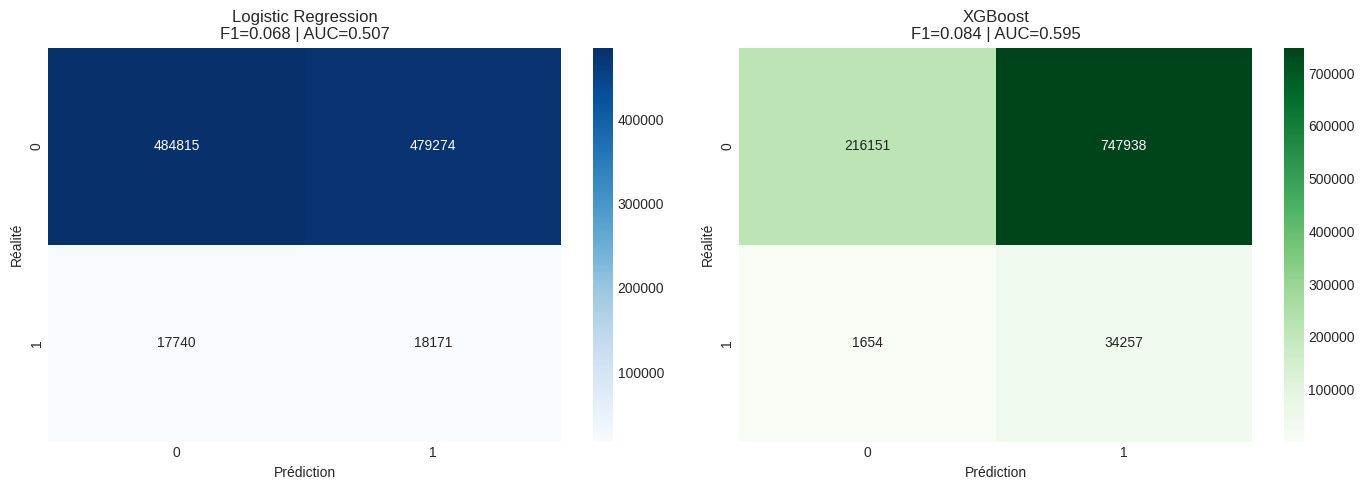

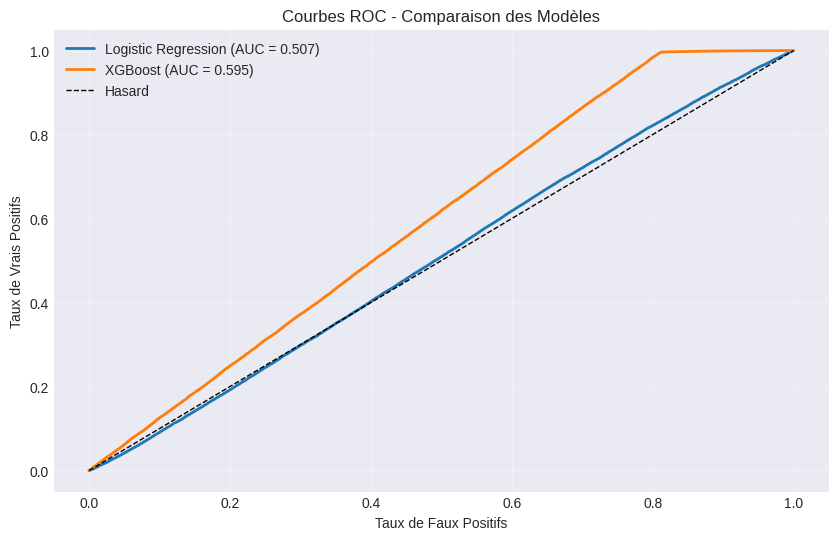

In [29]:
# model d'évaluation
print("\n" + "=" * 60)
print("ÉVALUATION DES MODÈLES")
print("=" * 60)

# Prédictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Fonction d'évaluation
def evaluate_model(y_true, y_pred, y_proba, model_name):
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")

    # Métriques
    f1 = f1_score(y_true, y_pred)
    auc_score = roc_auc_score(y_true, y_proba)

    print(f"\nF1-Score : {f1:.4f}")
    print(f"AUC-ROC  : {auc_score:.4f}")

    print(f"\nRapport de classification :")
    print(classification_report(y_true, y_pred, target_names=['Légitime', 'Fraude']))

    return f1, auc_score

# Évaluation
f1_lr, auc_lr = evaluate_model(y_test, y_pred_lr, y_pred_proba_lr, "LOGISTIC REGRESSION")
f1_xgb, auc_xgb = evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb, "XGBOOST")

# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Logistic Regression\nF1={f1_lr:.3f} | AUC={auc_lr:.3f}')
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Réalité')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'XGBoost\nF1={f1_xgb:.3f} | AUC={auc_xgb:.3f}')
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Réalité')

plt.tight_layout()
plt.show()

# Courbes ROC
plt.figure(figsize=(10, 6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Hasard', linewidth=1)

plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbes ROC - Comparaison des Modèles')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [31]:
# choix du meilleur model
print("\n" + "=" * 60)
print("SÉLECTION DU MEILLEUR MODÈLE")
print("=" * 60)

results = {
    'Logistic Regression': {'F1': f1_lr, 'AUC': auc_lr},
    'XGBoost': {'F1': f1_xgb, 'AUC': auc_xgb}
}

print("\nRésumé des performances :")
for model, scores in results.items():
    print(f"  {model:25s} | F1: {scores['F1']:.4f} | AUC: {scores['AUC']:.4f}")

# Sélection basée sur F1-score
best_model_name = max(results, key=lambda x: results[x]['F1'])
best_model = xgb_model if best_model_name == 'XGBoost' else lr_model

print(f"\n🏆 MEILLEUR MODÈLE : {best_model_name}")
print(f"   F1-Score : {results[best_model_name]['F1']:.4f}")
print(f"   AUC-ROC  : {results[best_model_name]['AUC']:.4f}")


SÉLECTION DU MEILLEUR MODÈLE

Résumé des performances :
  Logistic Regression       | F1: 0.0681 | AUC: 0.5067
  XGBoost                   | F1: 0.0837 | AUC: 0.5950

🏆 MEILLEUR MODÈLE : XGBoost
   F1-Score : 0.0837
   AUC-ROC  : 0.5950


In [33]:
print("\n" + "=" * 60)
print("EXPORT DU MODÈLE")
print("=" * 60)

# Sauvegarde du modèle
model_filename = '/content/drive/MyDrive/ML/fraud_detection_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump({
        'model': best_model,
        'scaler': scaler,
        'label_encoders': label_encoders,
        'feature_names': X.columns.tolist(),
        'model_name': best_model_name
    }, f)

print(f"✓ Modèle sauvegardé : {model_filename}")
print(f"  - Modèle : {best_model_name}")
print(f"  - Scaler : StandardScaler")
print(f"  - Label Encoders : {len(label_encoders)} encodeurs")
print(f"  - Features : {len(X.columns)} colonnes")


EXPORT DU MODÈLE
✓ Modèle sauvegardé : /content/drive/MyDrive/ML/fraud_detection_model.pkl
  - Modèle : XGBoost
  - Scaler : StandardScaler
  - Label Encoders : 12 encodeurs
  - Features : 17 colonnes


In [34]:
def predict_transaction(transaction_data, model_path='/content/drive/MyDrive/ML/fraud_detection_model.pkl'):
    """
    Prédit si une transaction est frauduleuse ou légitime.

    Args:
        transaction_data (dict): Dictionnaire contenant les features de la transaction
        model_path (str): Chemin vers le modèle sauvegardé

    Returns:
        dict: Résultat de la prédiction avec probabilité
    """
    # Charger le modèle
    with open(model_path, 'rb') as f:
        model_package = pickle.load(f)

    model = model_package['model']
    scaler = model_package['scaler']
    label_encoders = model_package['label_encoders']
    feature_names = model_package['feature_names']

    # Créer DataFrame
    df_input = pd.DataFrame([transaction_data])

    # Réorganiser les colonnes selon l'ordre d'entraînement
    for col in feature_names:
        if col not in df_input.columns:
            df_input[col] = 0  # Valeur par défaut si manquante

    df_input = df_input[feature_names]

    # Encoder les variables catégorielles
    for col, encoder in label_encoders.items():
        if col in df_input.columns:
            try:
                df_input[col] = encoder.transform(df_input[col].astype(str))
            except:
                df_input[col] = 0  # Valeur inconnue

    # Standardiser
    X_scaled = scaler.transform(df_input)

    # Prédire
    prediction = model.predict(X_scaled)[0]
    probability = model.predict_proba(X_scaled)[0]

    result = {
        'prediction': 'FRAUDE' if prediction == 1 else 'LÉGITIME',
        'fraud_probability': float(probability[1]),
        'confidence': float(max(probability))
    }

    return result


# Exemple d'utilisation
print("\n" + "=" * 60)
print("TEST DE LA FONCTION DE PRÉDICTION")
print("=" * 60)

# Exemple avec une transaction du test set
sample_transaction = X_test.iloc[0].to_dict()

print("\nTransaction test :")
for key, value in list(sample_transaction.items())[:5]:
    print(f"  {key}: {value}")
print("  ...")

result = predict_transaction(sample_transaction)

print(f"\n🔍 RÉSULTAT :")
print(f"  Prédiction      : {result['prediction']}")
print(f"  Prob. Fraude    : {result['fraud_probability']:.2%}")
print(f"  Confiance       : {result['confidence']:.2%}")

# Vérification avec la vraie valeur
actual = 'FRAUDE' if y_test.iloc[0] == 1 else 'LÉGITIME'
print(f"  Valeur réelle   : {actual}")
print(f"  Status          : {'✓ CORRECT' if result['prediction'] == actual else '✗ INCORRECT'}")


TEST DE LA FONCTION DE PRÉDICTION

Transaction test :
  transaction_id: 4843476.0
  timestamp: 602448.0
  sender_account: 560899.0
  receiver_account: 175250.0
  amount: 21.4
  ...

🔍 RÉSULTAT :
  Prédiction      : LÉGITIME
  Prob. Fraude    : 0.26%
  Confiance       : 99.74%
  Valeur réelle   : LÉGITIME
  Status          : ✓ CORRECT


In [35]:
print("\n" + "=" * 60)
print("RÉCAPITULATIF DU PROJET")
print("=" * 60)

print(f"""
📊 DATASET
  • Transactions totales    : {df.shape[0]:,}
  • Features                : {df.shape[1] - 1}
  • Taux de fraude          : {(y.sum() / len(y) * 100):.2f}%

🔧 PREPROCESSING
  • Valeurs manquantes      : Gérées
  • Variables catégorielles : {len(categorical_cols)} encodées
  • Variables numériques    : {len(numeric_cols)} standardisées
  • Déséquilibre            : SMOTE appliqué

🤖 MODÈLES TESTÉS
  • Logistic Regression     : F1={f1_lr:.4f} | AUC={auc_lr:.4f}
  • XGBoost                 : F1={f1_xgb:.4f} | AUC={auc_xgb:.4f}

🏆 MEILLEUR MODÈLE : {best_model_name}
  • F1-Score                : {results[best_model_name]['F1']:.4f}
  • AUC-ROC                 : {results[best_model_name]['AUC']:.4f}

💾 EXPORT
  • Fichier                 : fraud_detection_model.pkl
  • Fonction prête          : predict_transaction()

✅ PROJET TERMINÉ AVEC SUCCÈS
""")


RÉCAPITULATIF DU PROJET

📊 DATASET
  • Transactions totales    : 5,000,000
  • Features                : 17
  • Taux de fraude          : 3.59%

🔧 PREPROCESSING
  • Valeurs manquantes      : Gérées
  • Variables catégorielles : 12 encodées
  • Variables numériques    : 5 standardisées
  • Déséquilibre            : SMOTE appliqué

🤖 MODÈLES TESTÉS
  • Logistic Regression     : F1=0.0681 | AUC=0.5067
  • XGBoost                 : F1=0.0837 | AUC=0.5950

🏆 MEILLEUR MODÈLE : XGBoost
  • F1-Score                : 0.0837
  • AUC-ROC                 : 0.5950

💾 EXPORT
  • Fichier                 : fraud_detection_model.pkl
  • Fonction prête          : predict_transaction()

✅ PROJET TERMINÉ AVEC SUCCÈS

